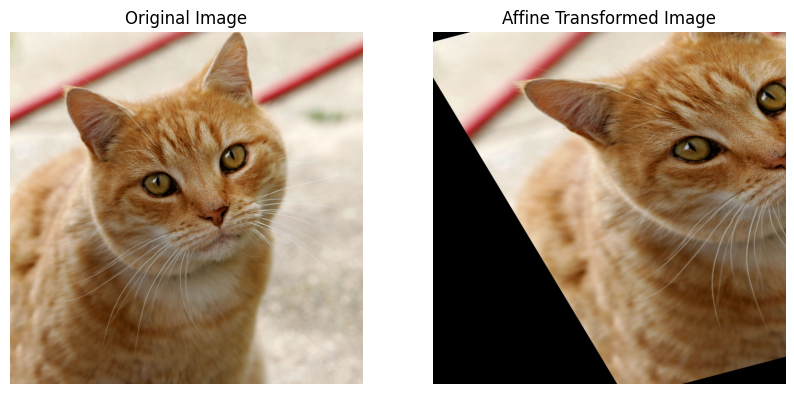

In [2]:
# Install (only needed in Colab)
!pip install opencv-python matplotlib

import cv2
import numpy as np
from matplotlib import pyplot as plt
import urllib.request

# -------------------------------
# 1. Download sample image
# -------------------------------
image_url = "https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg"

# Add a User-Agent header to mimic a browser request
opener = urllib.request.build_opener()
opener.addheaders = [('User-Agent', 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3')]
urllib.request.install_opener(opener)

urllib.request.urlretrieve(image_url, "sample.jpg")

# -------------------------------
# 2. Read image
# -------------------------------
img = cv2.imread("sample.jpg")

if img is None:
    print("Error loading image")
    exit()

# Convert BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Get image size
rows, cols, ch = img.shape

# -------------------------------
# 3. Define Affine Transformation
# -------------------------------

# Original points
pts1 = np.float32([[50,50], [200,50], [50,200]])

# New transformed points
pts2 = np.float32([[10,100], [200,50], [100,250]])

# Create transformation matrix
matrix = cv2.getAffineTransform(pts1, pts2)

# Apply affine transformation
transformed = cv2.warpAffine(img, matrix, (cols, rows))

# Convert for display
transformed_rgb = cv2.cvtColor(transformed, cv2.COLOR_BGR2RGB)

# -------------------------------
# 4. Display images
# -------------------------------
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Affine Transformed Image")
plt.imshow(transformed_rgb)
plt.axis('off')

plt.show()